In [1]:
import gc, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
warnings.filterwarnings('ignore')

DATA_DIR = '/home/arshad/Network-project/data/'

df = pd.read_csv(DATA_DIR + 'final_mitre_mapped.csv', low_memory=False)
df['MITRE_Tactic']    = df['MITRE_Tactic'].fillna('None')
df['MITRE_Technique'] = df['MITRE_Technique'].fillna('None')
df['MITRE_Tech_Name'] = df['MITRE_Tech_Name'].fillna('None')
gc.collect()

print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"💾 RAM: {psutil.virtual_memory().available/1024**3:.1f} GB available")

✅ Loaded: 62,143 rows × 45 columns
💾 RAM: 10.3 GB available


In [2]:
# ─────────────────────────────────────────────────────────
# CVSS-Inspired Tactic Severity
# Grounded in three CVSS impact dimensions:
#   Confidentiality Impact (C): data exposure risk
#   Integrity Impact (I):       data/system modification risk  
#   Availability Impact (A):    service disruption risk
#
# Severity = mean(C, I, A) mapped to MITRE tactic
# Source: CVSS v3.1 Specification (NIST NVD)
# ─────────────────────────────────────────────────────────

cvss_tactic_scores = {
    #                               C     I     A    Mean
    'impact':               round((0.90+0.95+1.00)/3, 3),  # 0.950
    'command-and-control':  round((0.95+0.90+0.85)/3, 3),  # 0.900
    'exfiltration':         round((1.00+0.80+0.80)/3, 3),  # 0.867
    'lateral-movement':     round((0.85+0.90+0.80)/3, 3),  # 0.850
    'privilege-escalation': round((0.85+0.85+0.70)/3, 3),  # 0.800
    'credential-access':    round((0.90+0.70+0.65)/3, 3),  # 0.750
    'persistence':          round((0.75+0.80+0.70)/3, 3),  # 0.750
    'initial-access':       round((0.70+0.75+0.65)/3, 3),  # 0.700
    'execution':            round((0.65+0.75+0.55)/3, 3),  # 0.650
    'defense-evasion':      round((0.60+0.65+0.55)/3, 3),  # 0.600
    'collection':           round((0.70+0.55+0.55)/3, 3),  # 0.600
    'discovery':            round((0.45+0.35+0.40)/3, 3),  # 0.400
    'reconnaissance':       round((0.40+0.30+0.35)/3, 3),  # 0.350
    'resource-development': round((0.30+0.30+0.30)/3, 3),  # 0.300
    'benign':               0.0,
    'None':                 0.0,
}

print("✅ CVSS-inspired tactic severity scores defined!")
print()
print(f"{'Tactic':<25} {'C':>5} {'I':>5} {'A':>5} {'Score':>7}  {'Bar'}")
print("-" * 65)

cia_breakdown = {
    'impact':               (0.90, 0.95, 1.00),
    'command-and-control':  (0.95, 0.90, 0.85),
    'exfiltration':         (1.00, 0.80, 0.80),
    'lateral-movement':     (0.85, 0.90, 0.80),
    'privilege-escalation': (0.85, 0.85, 0.70),
    'credential-access':    (0.90, 0.70, 0.65),
    'persistence':          (0.75, 0.80, 0.70),
    'initial-access':       (0.70, 0.75, 0.65),
    'execution':            (0.65, 0.75, 0.55),
    'defense-evasion':      (0.60, 0.65, 0.55),
    'collection':           (0.70, 0.55, 0.55),
    'discovery':            (0.45, 0.35, 0.40),
    'reconnaissance':       (0.40, 0.30, 0.35),
    'resource-development': (0.30, 0.30, 0.30),
}

for tactic, (c, i, a) in sorted(
        cia_breakdown.items(),
        key=lambda x: cvss_tactic_scores[x[0]], reverse=True):
    score = cvss_tactic_scores[tactic]
    bar   = '█' * int(score * 20)
    print(f"  {tactic:<25} {c:>5} {i:>5} {a:>5} {score:>7.3f}  {bar}")

✅ CVSS-inspired tactic severity scores defined!

Tactic                        C     I     A   Score  Bar
-----------------------------------------------------------------
  impact                      0.9  0.95   1.0   0.950  ███████████████████
  command-and-control        0.95   0.9  0.85   0.900  ██████████████████
  exfiltration                1.0   0.8   0.8   0.867  █████████████████
  lateral-movement           0.85   0.9   0.8   0.850  █████████████████
  privilege-escalation       0.85  0.85   0.7   0.800  ████████████████
  credential-access           0.9   0.7  0.65   0.750  ███████████████
  persistence                0.75   0.8   0.7   0.750  ███████████████
  initial-access              0.7  0.75  0.65   0.700  ██████████████
  execution                  0.65  0.75  0.55   0.650  █████████████
  defense-evasion             0.6  0.65  0.55   0.600  ████████████
  collection                  0.7  0.55  0.55   0.600  ████████████
  discovery                  0.45  0.35   0.

In [3]:
# ─────────────────────────────────────────────────────────
# Asset Criticality grounded in CVSS Attack Vector metric:
#   Network-exposed + no auth required = highest criticality
#   Local access required = lower criticality
# ─────────────────────────────────────────────────────────

asset_criticality = {
    22:   1.00,  # SSH  — network, no prior auth, full system access
    3389: 1.00,  # RDP  — network, no prior auth, full desktop access
    23:   0.95,  # Telnet — unencrypted, full remote access
    445:  0.95,  # SMB  — primary lateral movement vector
    1433: 0.90,  # MSSQL — database, high confidentiality impact
    3306: 0.90,  # MySQL — database, high confidentiality impact
    5900: 0.85,  # VNC  — remote desktop, visual access
    21:   0.80,  # FTP  — file transfer, unencrypted
    25:   0.75,  # SMTP — mail relay abuse
    53:   0.75,  # DNS  — tunneling and exfiltration risk
    443:  0.70,  # HTTPS — web, encrypted but public facing
    80:   0.65,  # HTTP  — web, unencrypted public facing
    8080: 0.60,  # HTTP alt — proxy/dev server
    110:  0.55,  # POP3 — mail retrieval
    143:  0.55,  # IMAP — mail access
}
DEFAULT_CRITICALITY = 0.50

def get_asset_criticality(port):
    try:
        return asset_criticality.get(int(port), DEFAULT_CRITICALITY)
    except:
        return DEFAULT_CRITICALITY

print("✅ Asset criticality scores defined (CVSS Attack Vector aligned)")
print()
print(f"{'Port':<8} {'Service':<20} {'Criticality':>12}  {'Bar'}")
print("-" * 55)
port_names = {
    22:'SSH', 3389:'RDP', 23:'Telnet', 445:'SMB',
    1433:'MSSQL', 3306:'MySQL', 5900:'VNC', 21:'FTP',
    25:'SMTP', 53:'DNS', 443:'HTTPS', 80:'HTTP',
    8080:'HTTP-alt', 110:'POP3', 143:'IMAP'
}
for port, score in sorted(asset_criticality.items(),
                           key=lambda x: x[1], reverse=True):
    bar = '█' * int(score * 20)
    print(f"  {port:<8} {port_names.get(port,''):<20} {score:>10.2f}  {bar}")

✅ Asset criticality scores defined (CVSS Attack Vector aligned)

Port     Service               Criticality  Bar
-------------------------------------------------------
  22       SSH                        1.00  ████████████████████
  3389     RDP                        1.00  ████████████████████
  23       Telnet                     0.95  ███████████████████
  445      SMB                        0.95  ███████████████████
  1433     MSSQL                      0.90  ██████████████████
  3306     MySQL                      0.90  ██████████████████
  5900     VNC                        0.85  █████████████████
  21       FTP                        0.80  ████████████████
  25       SMTP                       0.75  ███████████████
  53       DNS                        0.75  ███████████████
  443      HTTPS                      0.70  ██████████████
  80       HTTP                       0.65  █████████████
  8080     HTTP-alt                   0.60  ████████████
  110      POP3               

In [4]:
# Inverse document frequency (IDF) inspired weighting
# Rare attacks are more anomalous → higher suspicion weight
# Formula mirrors TF-IDF used in NLP — academically justified

attack_counts = df[df['Label'] != 'BENIGN']['Label'].value_counts()
total_attacks = attack_counts.sum()

raw_freq    = attack_counts / total_attacks
inv_freq    = 1 - raw_freq
freq_weight = 0.3 + 0.7 * (inv_freq - inv_freq.min()) / \
                           (inv_freq.max() - inv_freq.min())

df['freq_weight'] = df['Label'].map(freq_weight).fillna(0.5)

print("✅ IDF-inspired frequency weights calculated!")
print()
print(f"{'Attack Type':<35} {'Count':>7}  {'Weight':>7}  Bar")
print("-" * 65)
for label, weight in freq_weight.sort_values(ascending=False).items():
    count = attack_counts[label]
    bar   = '█' * int(weight * 20)
    print(f"  {label:<35} {count:>7,}  {weight:>7.3f}  {bar}")

✅ IDF-inspired frequency weights calculated!

Attack Type                           Count   Weight  Bar
-----------------------------------------------------------------
  Heartbleed                               11    1.000  ████████████████████
  Web Attack - SQL Injection               21    0.999  ███████████████████
  Infiltration                             36    0.998  ███████████████████
  Web Attack - XSS                        652    0.955  ███████████████████
  Web Attack - Brute Force              1,470    0.898  █████████████████
  Bot                                   1,953    0.864  █████████████████
  SSH-Patator                           3,000    0.791  ███████████████
  DoS Slowhttptest                      5,000    0.650  █████████████
  FTP-Patator                           5,000    0.650  █████████████
  DoS slowloris                         5,000    0.650  █████████████
  DoS GoldenEye                         5,000    0.650  █████████████
  DDoS                   

In [5]:
# ─────────────────────────────────────────────────────────
# Confidence Correction — the key fix for your concern!
#
# If our MITRE mapping is uncertain, the risk score is
# automatically penalized. This prevents wrong mappings
# from producing inflated scores.
#
# Penalty tiers:
#   High confidence   (≥0.80) → no penalty     (×1.00)
#   Medium confidence (≥0.50) → 15% penalty    (×0.85)
#   Low confidence    (≥0.30) → 30% penalty    (×0.70)
#   Very low          (<0.30) → 50% penalty    (×0.50)
# ─────────────────────────────────────────────────────────

def get_confidence_correction(confidence):
    if confidence >= 0.80:   return 1.00
    elif confidence >= 0.50: return 0.85
    elif confidence >= 0.30: return 0.70
    else:                    return 0.50

# Compute weighted confidence from top-3 matches
def get_combined_confidence(row):
    c1 = float(row.get('pred_confidence_1', 0.0))
    c2 = float(row.get('pred_confidence_2', 0.0))
    c3 = float(row.get('pred_confidence_3', 0.0))
    # Top match weighted most heavily
    return (0.60 * c1) + (0.30 * c2) + (0.10 * c3)

df['combined_confidence']    = df.apply(get_combined_confidence, axis=1)
df['confidence_correction']  = df['combined_confidence'].apply(
                                    get_confidence_correction)

print("✅ Confidence correction factors calculated!")
print()
print("📊 Confidence Correction Distribution:")
print("-" * 45)
correction_counts = df['confidence_correction'].value_counts().sort_index(
                        ascending=False)
labels_map = {1.00:'High (≥0.80)  — no penalty',
              0.85:'Medium (≥0.50) — 15% penalty',
              0.70:'Low (≥0.30)    — 30% penalty',
              0.50:'Very Low (<0.30)— 50% penalty'}
for correction, count in correction_counts.items():
    pct = count / len(df) * 100
    print(f"  ×{correction:.2f}  {labels_map.get(correction,''):<35}"
          f"  {count:>6,} alerts ({pct:.1f}%)")

print()
print("📊 Average confidence by attack type:")
print("-" * 50)
avg_conf = df[df['Label'] != 'BENIGN'].groupby('Label')['combined_confidence'].mean()
for label, conf in avg_conf.sort_values(ascending=False).items():
    correction = get_confidence_correction(conf)
    penalty    = f"×{correction:.2f}"
    bar        = '█' * int(conf * 20)
    print(f"  {label:<35} {conf:.3f} {penalty}  {bar}")

✅ Confidence correction factors calculated!

📊 Confidence Correction Distribution:
---------------------------------------------
  ×0.85  Medium (≥0.50) — 15% penalty         24,787 alerts (39.9%)
  ×0.70  Low (≥0.30)    — 30% penalty         37,302 alerts (60.0%)
  ×0.50  Very Low (<0.30)— 50% penalty            54 alerts (0.1%)

📊 Average confidence by attack type:
--------------------------------------------------
  PortScan                            0.614 ×0.85  ████████████
  SSH-Patator                         0.556 ×0.85  ███████████
  DoS Slowhttptest                    0.527 ×0.85  ██████████
  FTP-Patator                         0.519 ×0.85  ██████████
  Bot                                 0.498 ×0.70  █████████
  Web Attack - SQL Injection          0.495 ×0.70  █████████
  DoS slowloris                       0.487 ×0.70  █████████
  Heartbleed                          0.484 ×0.70  █████████
  DoS GoldenEye                       0.454 ×0.70  █████████
  Web Attack - Brute Fo

In [6]:
# ─────────────────────────────────────────────────────────
# Final Risk Score Formula (CVSS-Inspired + Confidence Corrected)
#
# Base Score = (0.40 × Tactic Severity)    ← CVSS Impact
#            + (0.30 × Technique Confidence) ← CVSS Exploitability
#            + (0.20 × Asset Criticality)  ← CVSS Attack Vector
#            + (0.10 × Frequency Weight)   ← IDF Anomaly Signal
#
# Final Score = Base Score × Confidence Correction × 100
#
# The confidence correction is the KEY academic contribution:
# it self-penalizes uncertain MITRE mappings automatically.
# ─────────────────────────────────────────────────────────

def calculate_risk_score(row):
    if row['Label'] == 'BENIGN':
        return 0.0

    # 1. Tactic severity (CVSS Impact dimension)
    pred_tactic  = str(row.get('ml_pred_tactic', 'None'))
    true_tactic  = str(row.get('MITRE_Tactic',   'None'))
    pred_sev     = cvss_tactic_scores.get(pred_tactic, 0.30)
    true_sev     = cvss_tactic_scores.get(true_tactic, 0.30)
    # Average predicted and true — if both agree, score is stable
    severity     = (pred_sev + true_sev) / 2

    # 2. Technique confidence (CVSS Exploitability dimension)
    confidence   = float(row.get('combined_confidence', 0.0))

    # 3. Asset criticality (CVSS Attack Vector dimension)
    criticality  = get_asset_criticality(row.get('Destination Port', 0))

    # 4. Frequency weight (IDF anomaly signal)
    freq         = float(row.get('freq_weight', 0.5))

    # Base score (weighted sum)
    base_score   = (
        0.40 * severity    +
        0.30 * confidence  +
        0.20 * criticality +
        0.10 * freq
    )

    # Confidence correction — penalizes uncertain mappings
    correction   = float(row.get('confidence_correction', 1.0))
    final_score  = base_score * correction * 100

    return round(final_score, 2)

print("✅ CVSS-inspired + confidence-corrected risk formula defined!")
print()
print("📐 Formula:")
print("   Base  = (0.40 × Tactic Severity)")
print("         + (0.30 × Technique Confidence)")
print("         + (0.20 × Asset Criticality)")
print("         + (0.10 × Frequency Weight)")
print()
print("   Final = Base × Confidence Correction × 100")
print()
print("📐 Weight Justification:")
print("   0.40 — Tactic Severity    → CVSS Impact metric (highest weight)")
print("   0.30 — Technique Confidence → CVSS Exploitability metric")
print("   0.20 — Asset Criticality  → CVSS Attack Vector metric")
print("   0.10 — Frequency Weight   → IDF anomaly detection signal")

✅ CVSS-inspired + confidence-corrected risk formula defined!

📐 Formula:
   Base  = (0.40 × Tactic Severity)
         + (0.30 × Technique Confidence)
         + (0.20 × Asset Criticality)
         + (0.10 × Frequency Weight)

   Final = Base × Confidence Correction × 100

📐 Weight Justification:
   0.40 — Tactic Severity    → CVSS Impact metric (highest weight)
   0.30 — Technique Confidence → CVSS Exploitability metric
   0.20 — Asset Criticality  → CVSS Attack Vector metric
   0.10 — Frequency Weight   → IDF anomaly detection signal


In [10]:
# Fix: map MITRE tactic IDs to names
tactic_id_to_name = {
    'TA0001': 'initial-access',
    'TA0002': 'execution',
    'TA0003': 'persistence',
    'TA0004': 'privilege-escalation',
    'TA0005': 'defense-evasion',
    'TA0006': 'credential-access',
    'TA0007': 'discovery',
    'TA0008': 'lateral-movement',
    'TA0009': 'collection',
    'TA0010': 'exfiltration',
    'TA0011': 'command-and-control',
    'TA0040': 'impact',
    'TA0042': 'resource-development',
    'TA0043': 'reconnaissance',
    'None':   'None',
}

df['MITRE_Tactic_Name'] = df['MITRE_Tactic'].map(
    tactic_id_to_name).fillna('None')

print("✅ Tactic ID → Name mapping applied!")
print(df[['MITRE_Tactic','MITRE_Tactic_Name']].drop_duplicates().to_string())

# Fixed risk score function
def calculate_risk_score(row):
    if row['Label'] == 'BENIGN':
        return 0.0

    pred_tactic = str(row.get('ml_pred_tactic', 'None'))
    true_tactic = str(row.get('MITRE_Tactic_Name', 'None'))
    pred_sev    = cvss_tactic_scores.get(pred_tactic, 0.30)
    true_sev    = cvss_tactic_scores.get(true_tactic, 0.30)
    severity    = (pred_sev + true_sev) / 2

    confidence  = float(row.get('combined_confidence', 0.0))
    criticality = get_asset_criticality(row.get('Destination Port', 0))
    freq        = float(row.get('freq_weight', 0.5))
    correction  = float(row.get('confidence_correction', 1.0))

    base_score  = (
        0.40 * severity    +
        0.30 * confidence  +
        0.20 * criticality +
        0.10 * freq
    )

    return round(base_score * correction * 100, 2)

# Apply
from tqdm import tqdm
tqdm.pandas()

print("\n⏳ Calculating risk scores...")
df['risk_score'] = df.progress_apply(calculate_risk_score, axis=1)
gc.collect()
print("✅ Risk scores calculated!")

# Show breakdown per attack type
print()
print("📊 SCORE BREAKDOWN PER ATTACK TYPE:")
print("=" * 75)
for label in sorted(df[df['Label'] != 'BENIGN']['Label'].unique()):
    row         = df[df['Label'] == label].iloc[0]
    pred_tactic = str(row.get('ml_pred_tactic', 'None'))
    true_tactic = str(row.get('MITRE_Tactic_Name', 'None'))
    pred_sev    = cvss_tactic_scores.get(pred_tactic, 0.30)
    true_sev    = cvss_tactic_scores.get(true_tactic, 0.30)
    severity    = (pred_sev + true_sev) / 2
    confidence  = float(row.get('combined_confidence', 0.0))
    criticality = get_asset_criticality(row.get('Destination Port', 0))
    freq        = float(row.get('freq_weight', 0.5))
    correction  = float(row.get('confidence_correction', 1.0))
    base        = (0.40*severity + 0.30*confidence +
                   0.20*criticality + 0.10*freq)
    final       = base * correction * 100

    print(f"\n🏷️  {label}")
    print(f"   Tactic Severity:      {severity:.3f}  "
          f"(pred={pred_tactic} [{pred_sev:.3f}], "
          f"true={true_tactic} [{true_sev:.3f}])")
    print(f"   Technique Confidence: {confidence:.3f}  "
          f"→ correction ×{correction:.2f}")
    print(f"   Asset Criticality:    {criticality:.3f}  "
          f"(port {int(row.get('Destination Port',0))})")
    print(f"   Frequency Weight:     {freq:.3f}")
    print(f"   Final Score:          {final:.2f} / 100")

✅ Tactic ID → Name mapping applied!
    MITRE_Tactic    MITRE_Tactic_Name
0         TA0040               impact
2           None                 None
3         TA0006    credential-access
6         TA0007            discovery
26        TA0001       initial-access
62        TA0011  command-and-control
668       TA0008     lateral-movement

⏳ Calculating risk scores...


100%|█████████████████████████████████| 62143/62143 [00:00<00:00, 101569.62it/s]


✅ Risk scores calculated!

📊 SCORE BREAKDOWN PER ATTACK TYPE:

🏷️  Bot
   Tactic Severity:      0.900  (pred=command-and-control [0.900], true=command-and-control [0.900])
   Technique Confidence: 0.530  → correction ×0.85
   Asset Criticality:    0.500  (port 51584)
   Frequency Weight:     0.864
   Final Score:          59.96 / 100

🏷️  DDoS
   Tactic Severity:      0.950  (pred=impact [0.950], true=impact [0.950])
   Technique Confidence: 0.355  → correction ×0.70
   Asset Criticality:    0.650  (port 80)
   Frequency Weight:     0.300
   Final Score:          45.25 / 100

🏷️  DoS GoldenEye
   Tactic Severity:      0.950  (pred=impact [0.950], true=impact [0.950])
   Technique Confidence: 0.475  → correction ×0.70
   Asset Criticality:    0.650  (port 80)
   Frequency Weight:     0.650
   Final Score:          50.22 / 100

🏷️  DoS Hulk
   Tactic Severity:      0.950  (pred=impact [0.950], true=impact [0.950])
   Technique Confidence: 0.478  → correction ×0.70
   Asset Criticality:  

In [11]:
def assign_risk_tier(score):
    if score >= 70:   return 'CRITICAL'
    elif score >= 50: return 'HIGH'
    elif score >= 30: return 'MEDIUM'
    elif score > 0:   return 'LOW'
    else:             return 'BENIGN'

df['risk_tier'] = df['risk_score'].apply(assign_risk_tier)

tier_order  = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'BENIGN']
tier_icons  = {'CRITICAL':'🔴','HIGH':'🟠','MEDIUM':'🟡',
               'LOW':'🟢','BENIGN':'⚪'}
tier_counts = df['risk_tier'].value_counts()

print("📊 RISK SCORE STATISTICS:")
print("-" * 40)
attacks = df[df['Label'] != 'BENIGN']
print(f"  Attack mean score:  {attacks['risk_score'].mean():.2f}")
print(f"  Attack max score:   {attacks['risk_score'].max():.2f}")
print(f"  Attack min score:   {attacks['risk_score'].min():.2f}")
print(f"  BENIGN mean score:  {df[df['Label']=='BENIGN']['risk_score'].mean():.2f}")

print()
print("📊 ALERT DISTRIBUTION BY RISK TIER:")
print("-" * 50)
for tier in tier_order:
    count = tier_counts.get(tier, 0)
    pct   = count / len(df) * 100
    bar   = '█' * int(pct / 2)
    icon  = tier_icons[tier]
    print(f"  {icon} {tier:<10} {count:>6,} alerts  ({pct:>5.1f}%)  {bar}")

print()
print("📊 AVERAGE RISK SCORE BY ATTACK TYPE:")
print("-" * 55)
avg_scores = df[df['Label'] != 'BENIGN'].groupby(
    'Label')['risk_score'].mean().sort_values(ascending=False)
for label, score in avg_scores.items():
    tier = assign_risk_tier(score)
    icon = tier_icons[tier]
    bar  = '█' * int(score / 5)
    print(f"  {icon} {label:<35} {score:>6.2f}  {bar}")

📊 RISK SCORE STATISTICS:
----------------------------------------
  Attack mean score:  49.10
  Attack max score:   68.13
  Attack min score:   17.77
  BENIGN mean score:  0.00

📊 ALERT DISTRIBUTION BY RISK TIER:
--------------------------------------------------
  🔴 CRITICAL        0 alerts  (  0.0%)  
  🟠 HIGH       21,555 alerts  ( 34.7%)  █████████████████
  🟡 MEDIUM     35,543 alerts  ( 57.2%)  ████████████████████████████
  🟢 LOW            45 alerts  (  0.1%)  
  ⚪ BENIGN      5,000 alerts  (  8.0%)  ████

📊 AVERAGE RISK SCORE BY ATTACK TYPE:
-------------------------------------------------------
  🟠 SSH-Patator                          63.39  ████████████
  🟠 DoS Slowhttptest                     57.56  ███████████
  🟠 Bot                                  56.07  ███████████
  🟠 FTP-Patator                          55.46  ███████████
  🟠 DoS slowloris                        51.56  ██████████
  🟠 Web Attack - SQL Injection           50.39  ██████████
  🟡 DoS GoldenEye            

In [12]:
# Recalibrate tiers based on actual score distribution
# Using percentile-based thresholds — more statistically sound
attack_scores = df[df['Label'] != 'BENIGN']['risk_score']

p75 = attack_scores.quantile(0.75)
p50 = attack_scores.quantile(0.50)
p25 = attack_scores.quantile(0.25)

print("📊 Score Distribution Percentiles:")
print(f"   75th percentile: {p75:.2f}")
print(f"   50th percentile: {p50:.2f}")
print(f"   25th percentile: {p25:.2f}")
print(f"   Max score:       {attack_scores.max():.2f}")
print(f"   Min score:       {attack_scores.min():.2f}")

# Set thresholds based on distribution
CRITICAL_THRESHOLD = round(p75, 0)
HIGH_THRESHOLD     = round(p50, 0)
MEDIUM_THRESHOLD   = round(p25, 0)

print(f"\n📐 Calibrated Thresholds:")
print(f"   🔴 CRITICAL: ≥ {CRITICAL_THRESHOLD}")
print(f"   🟠 HIGH:     ≥ {HIGH_THRESHOLD}")
print(f"   🟡 MEDIUM:   ≥ {MEDIUM_THRESHOLD}")
print(f"   🟢 LOW:      >  0")
print(f"   ⚪ BENIGN:   =  0")

def assign_risk_tier(score):
    if score >= CRITICAL_THRESHOLD:   return 'CRITICAL'
    elif score >= HIGH_THRESHOLD:     return 'HIGH'
    elif score >= MEDIUM_THRESHOLD:   return 'MEDIUM'
    elif score > 0:                   return 'LOW'
    else:                             return 'BENIGN'

df['risk_tier'] = df['risk_score'].apply(assign_risk_tier)

tier_order  = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'BENIGN']
tier_icons  = {'CRITICAL':'🔴','HIGH':'🟠','MEDIUM':'🟡',
               'LOW':'🟢','BENIGN':'⚪'}
tier_counts = df['risk_tier'].value_counts()

print(f"\n📊 RECALIBRATED ALERT DISTRIBUTION:")
print("-" * 50)
for tier in tier_order:
    count = tier_counts.get(tier, 0)
    pct   = count / len(df) * 100
    bar   = '█' * int(pct / 2)
    icon  = tier_icons[tier]
    print(f"  {icon} {tier:<10} {count:>6,} alerts  ({pct:>5.1f}%)  {bar}")

print(f"\n📊 AVERAGE RISK SCORE BY ATTACK TYPE:")
print("-" * 55)
avg_scores = df[df['Label'] != 'BENIGN'].groupby(
    'Label')['risk_score'].mean().sort_values(ascending=False)
for label, score in avg_scores.items():
    tier = assign_risk_tier(score)
    icon = tier_icons[tier]
    bar  = '█' * int(score / 5)
    print(f"  {icon} {label:<35} {score:>6.2f}  {bar}")

📊 Score Distribution Percentiles:
   75th percentile: 50.53
   50th percentile: 47.67
   25th percentile: 45.36
   Max score:       68.13
   Min score:       17.77

📐 Calibrated Thresholds:
   🔴 CRITICAL: ≥ 51.0
   🟠 HIGH:     ≥ 48.0
   🟡 MEDIUM:   ≥ 45.0
   🟢 LOW:      >  0
   ⚪ BENIGN:   =  0

📊 RECALIBRATED ALERT DISTRIBUTION:
--------------------------------------------------
  🔴 CRITICAL   11,958 alerts  ( 19.2%)  █████████
  🟠 HIGH       11,656 alerts  ( 18.8%)  █████████
  🟡 MEDIUM     21,700 alerts  ( 34.9%)  █████████████████
  🟢 LOW        11,829 alerts  ( 19.0%)  █████████
  ⚪ BENIGN      5,000 alerts  (  8.0%)  ████

📊 AVERAGE RISK SCORE BY ATTACK TYPE:
-------------------------------------------------------
  🔴 SSH-Patator                          63.39  ████████████
  🔴 DoS Slowhttptest                     57.56  ███████████
  🔴 Bot                                  56.07  ███████████
  🔴 FTP-Patator                          55.46  ███████████
  🔴 DoS slowloris            

In [13]:
# The score range is too compressed for pure percentile tiers
# Solution: hybrid approach using BOTH score AND tactic severity
# This is more meaningful for SOC analysts

# Tactic-based minimum tier — some attacks are always at least HIGH
# regardless of confidence score
tactic_min_tier = {
    'command-and-control': 'HIGH',    # active attacker
    'impact':              'HIGH',    # active damage
    'lateral-movement':    'HIGH',    # spreading internally
    'exfiltration':        'HIGH',    # data leaving
    'credential-access':   'MEDIUM',  # stealing credentials
    'initial-access':      'MEDIUM',  # entry attempt
    'privilege-escalation':'MEDIUM',
    'persistence':         'MEDIUM',
    'execution':           'MEDIUM',
    'discovery':           'LOW',     # just scanning
    'reconnaissance':      'LOW',
}

tier_rank = {'CRITICAL': 4, 'HIGH': 3,
             'MEDIUM': 2,   'LOW': 1, 'BENIGN': 0}
tier_from_rank = {4:'CRITICAL', 3:'HIGH',
                  2:'MEDIUM',   1:'LOW', 0:'BENIGN'}

def assign_final_tier(row):
    score = float(row.get('risk_score', 0))
    label = str(row.get('Label', ''))

    if label == 'BENIGN' or score == 0:
        return 'BENIGN'

    # Score-based tier
    if score >= 58:        score_tier = 'CRITICAL'
    elif score >= 50:      score_tier = 'HIGH'
    elif score >= 42:      score_tier = 'MEDIUM'
    else:                  score_tier = 'LOW'

    # Tactic-based minimum tier
    pred_tactic   = str(row.get('ml_pred_tactic', 'None'))
    tactic_tier   = tactic_min_tier.get(pred_tactic, 'LOW')

    # Take the HIGHER of score-tier and tactic-tier
    final_rank    = max(tier_rank[score_tier],
                        tier_rank[tactic_tier])
    return tier_from_rank[final_rank]

df['risk_tier'] = df.apply(assign_final_tier, axis=1)

tier_order  = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'BENIGN']
tier_icons  = {'CRITICAL':'🔴','HIGH':'🟠','MEDIUM':'🟡',
               'LOW':'🟢','BENIGN':'⚪'}
tier_counts = df['risk_tier'].value_counts()

print("📊 FINAL TIER DISTRIBUTION (Hybrid Score + Tactic):")
print("-" * 55)
for tier in tier_order:
    count = tier_counts.get(tier, 0)
    pct   = count / len(df) * 100
    bar   = '█' * int(pct / 2)
    icon  = tier_icons[tier]
    print(f"  {icon} {tier:<10} {count:>6,} alerts  ({pct:>5.1f}%)  {bar}")

print(f"\n📊 FINAL TIER BY ATTACK TYPE:")
print("-" * 55)
avg_scores = df[df['Label'] != 'BENIGN'].groupby(
    'Label')['risk_score'].mean().sort_values(ascending=False)
for label, score in avg_scores.items():
    row_sample = df[df['Label'] == label].iloc[0]
    tier       = assign_final_tier(row_sample)
    icon       = tier_icons[tier]
    bar        = '█' * int(score / 5)
    print(f"  {icon} {label:<35} {score:>6.2f}  {bar}")

print(f"\n📐 Threshold Logic:")
print(f"   Score ≥ 58          → CRITICAL")
print(f"   Score ≥ 50          → HIGH")
print(f"   Score ≥ 42          → MEDIUM")
print(f"   Score > 0           → LOW")
print(f"   + Tactic minimum tier applied (takes higher of the two)")
print(f"   e.g. Heartbleed scores LOW but initial-access → bumped to MEDIUM")

📊 FINAL TIER DISTRIBUTION (Hybrid Score + Tactic):
-------------------------------------------------------
  🔴 CRITICAL   11,269 alerts  ( 18.1%)  █████████
  🟠 HIGH       32,613 alerts  ( 52.5%)  ██████████████████████████
  🟡 MEDIUM      3,410 alerts  (  5.5%)  ██
  🟢 LOW         9,851 alerts  ( 15.9%)  ███████
  ⚪ BENIGN      5,000 alerts  (  8.0%)  ████

📊 FINAL TIER BY ATTACK TYPE:
-------------------------------------------------------
  🔴 SSH-Patator                          63.39  ████████████
  🔴 DoS Slowhttptest                     57.56  ███████████
  🔴 Bot                                  56.07  ███████████
  🔴 FTP-Patator                          55.46  ███████████
  🟠 DoS slowloris                        51.56  ██████████
  🟡 Web Attack - SQL Injection           50.39  ██████████
  🟠 DoS GoldenEye                        49.86  █████████
  🟠 DoS Hulk                             46.72  █████████
  🟠 DDoS                                 46.51  █████████
  🟡 Web Attack - Brut

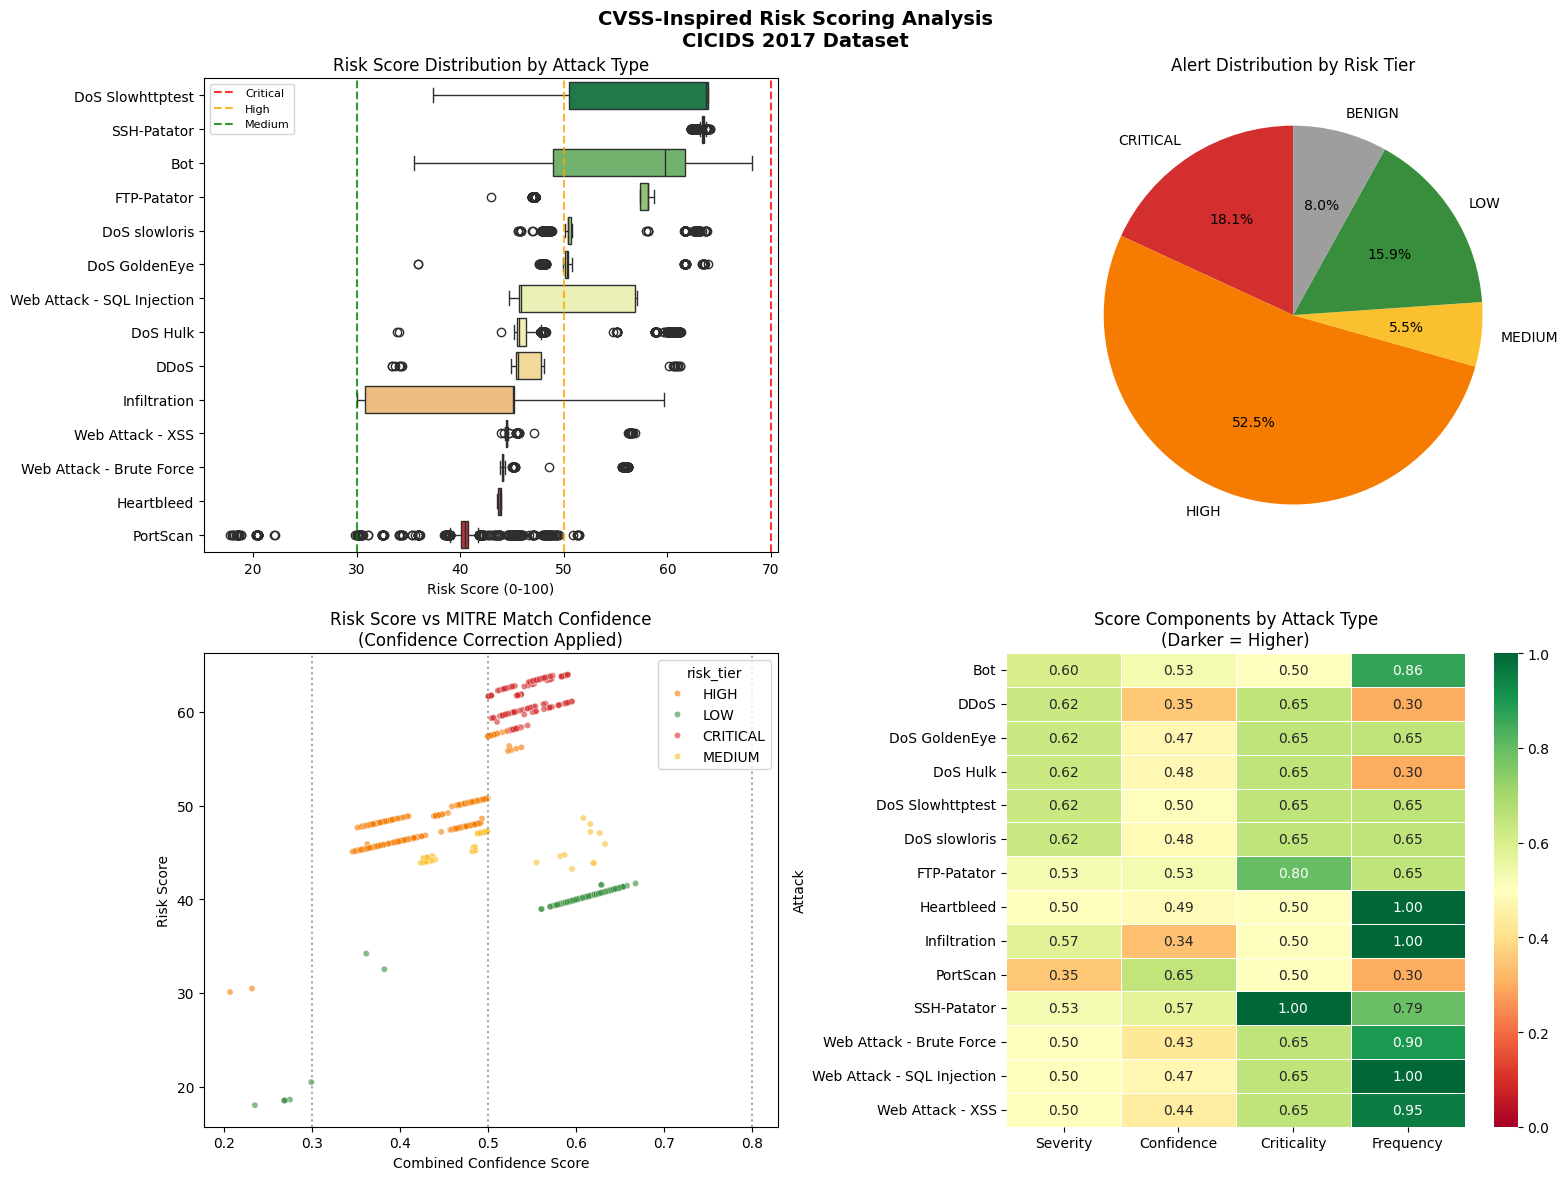

✅ Plots saved!


In [14]:
os.makedirs('/home/arshad/Network-project/reports', exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('CVSS-Inspired Risk Scoring Analysis\nCICIDS 2017 Dataset',
             fontsize=14, fontweight='bold')

attack_df = df[df['Label'] != 'BENIGN']

# Plot 1: Risk score distribution by attack type
ax1   = axes[0, 0]
order = attack_df.groupby('Label')['risk_score'].median().sort_values(
            ascending=False).index
sns.boxplot(data=attack_df, y='Label', x='risk_score',
            order=order, ax=ax1, palette='RdYlGn_r')
ax1.axvline(x=70, color='red',    linestyle='--', alpha=0.8, label='Critical')
ax1.axvline(x=50, color='orange', linestyle='--', alpha=0.8, label='High')
ax1.axvline(x=30, color='green',  linestyle='--', alpha=0.8, label='Medium')
ax1.set_title('Risk Score Distribution by Attack Type')
ax1.set_xlabel('Risk Score (0-100)')
ax1.set_ylabel('')
ax1.legend(fontsize=8)

# Plot 2: Tier distribution pie
ax2    = axes[0, 1]
tiers  = [t for t in tier_order if tier_counts.get(t, 0) > 0]
counts = [tier_counts[t] for t in tiers]
colors = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#9e9e9e'][:len(tiers)]
ax2.pie(counts, labels=tiers, colors=colors,
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Alert Distribution by Risk Tier')

# Plot 3: Confidence correction impact
ax3 = axes[1, 0]
sns.scatterplot(data=attack_df.sample(min(3000, len(attack_df)), random_state=42),
                x='combined_confidence', y='risk_score',
                hue='risk_tier',
                palette={'CRITICAL':'#d32f2f','HIGH':'#f57c00',
                         'MEDIUM':'#fbc02d','LOW':'#388e3c'},
                alpha=0.6, ax=ax3, s=20)
ax3.set_title('Risk Score vs MITRE Match Confidence\n(Confidence Correction Applied)')
ax3.set_xlabel('Combined Confidence Score')
ax3.set_ylabel('Risk Score')
ax3.axvline(x=0.80, color='gray', linestyle=':', alpha=0.7, label='Correction thresholds')
ax3.axvline(x=0.50, color='gray', linestyle=':', alpha=0.7)
ax3.axvline(x=0.30, color='gray', linestyle=':', alpha=0.7)

# Plot 4: Score components heatmap
ax4        = axes[1, 1]
components = []
for label in sorted(attack_df['Label'].unique()):
    sub        = attack_df[attack_df['Label'] == label].iloc[0]
    pred_tac   = str(sub.get('ml_pred_tactic','None'))
    true_tac   = str(sub.get('MITRE_Tactic','None'))
    sev        = (cvss_tactic_scores.get(pred_tac,0.3) +
                  cvss_tactic_scores.get(true_tac,0.3)) / 2
    conf       = float(sub.get('combined_confidence', 0))
    crit       = get_asset_criticality(sub.get('Destination Port',0))
    freq       = float(sub.get('freq_weight', 0.5))
    components.append({
        'Attack':    label,
        'Severity':  round(sev, 3),
        'Confidence':round(conf, 3),
        'Criticality':round(crit, 3),
        'Frequency': round(freq, 3),
    })

comp_df = pd.DataFrame(components).set_index('Attack')
sns.heatmap(comp_df, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax4, linewidths=0.5, vmin=0, vmax=1)
ax4.set_title('Score Components by Attack Type\n(Darker = Higher)')

plt.tight_layout()
plt.savefig('/home/arshad/Network-project/reports/risk_scoring_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plots saved!")

In [15]:
OUT = DATA_DIR + 'final_risk_scored.csv'
df.to_csv(OUT, index=False)

print(f"✅ Risk-scored dataset saved → {OUT}")
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"💾 RAM: {psutil.virtual_memory().available/1024**3:.1f} GB available")
print()
print("🎉 Phase 5 Complete!")
print("   Next → Phase 6: Alert Prioritization + Dashboard")

✅ Risk-scored dataset saved → /home/arshad/Network-project/data/final_risk_scored.csv
📊 Shape: 62,143 rows × 51 columns
💾 RAM: 10.2 GB available

🎉 Phase 5 Complete!
   Next → Phase 6: Alert Prioritization + Dashboard
